When chatting with Gregoire Aufort, he said that our model would be particularly appealing if the curves it can fit well are a "superset" of those fitted by the 2- and 4- parameter models. In this notebook, we design a test where we take the best-fit parameters from the galaxies which we already fitted by the 2- and 4- parameter models, and see if our curve can reproduce the curves obtained when re-evaluating those functions with the best fit parameters.

In [2]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, '../literature_fits')
import attenuation_curves
import fit_literature

# Testing Fitting Scripts

In [260]:
def get_data(in_data_dir, dust_mixture, full_Av_name='A_5542A', lam_min=0.1, lam_max=1.0):

    fname = os.path.join(in_data_dir, f'iob_codes_plus_Acurve_galprop_{dust_mixture}_all.dat')
    # fname = os.path.join(in_data_dir, f'iob_codes_plus_Acurve_galprop_{dust_mixture}_noBUG_full.dat')

    df = pd.read_csv(fname, sep='\t', header=0)

    lam_V = float(full_Av_name[2:-1])

    # Read wavelengths and attenuation curves
    use_cols = [x for x in df.columns if x.startswith('A_')]
    lam = np.array([float(x[2:-1]) for x in use_cols])
    m = (lam >= lam_min*1e4) & (lam <= lam_max*1e4)
    use_cols = [use_cols[i] for i in range(len(use_cols)) if m[i]]
    lam = lam[m]

    # Read attenuation curves
    A = df[use_cols].values
    A_V = df[full_Av_name].values
    A_over_Av = A / A_V[:, np.newaxis]

    # Get best-fit values of new attenuation curve
    new_pars = ['B_0', 'B_1s', 'B_2s', 'B_3']
    SB26_pars = df[new_pars].values

    # Store the galaxy_id and los info
    id_data = df[['galaxy_id', 'los']]

    return id_data, lam, lam_V, A_over_Av, A_V, SB26_pars

In [261]:
def func_SB26(lam, B0, B1s, B2s, B3):

    x = lam / 5542
    c = [0.4002, 285.6, 0.2092, 9.223, 1.016]
    B1 = B1s * 1e3
    B2 = B2s * 1e3

    y = (
        B0 * (np.exp(-c[1] * (x - c[0])**2) - np.exp(-c[1] * (1. - c[0])**2))
        + (B1 + B2 * (x - c[2])) * (x - c[2]) * (np.exp(-c[3] * x) - np.exp(-c[3]))
        + np.exp(B3 * (np.tanh(c[4]) - np.tanh(c[4] * x)))
    )

    return y


In [262]:
dust_mixture = 'MW'
dirname = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/deg_final_maybe'
# dirname = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/'
id_data, lam, lam_V, A_over_Av, Av, SB26_pars = get_data(dirname, dust_mixture);

In [263]:
idx = 91

# los = 5; gid = 540526
# los= 46; gid = 668284
gid = 42; los = 27 # DEFAULT FROM SB26
gid = 42; los = 20

idx = np.where((id_data['galaxy_id'] == gid) & (id_data['los'] == los))[0][0]

# idx = 1234
# idx = 0

print(idx)

# Initial guesses for 4-parameter fit
all_p0_4par = [
    [44.9, 7.56, 61.2, 0.],  # 'Calzetti'
    [38.7, 3.83, 6.34, 0.], #'SMC'
    [14.4, 6.52, 2.04, 0.0519], # 'MW'
    [4.47, 2.39, -0.988, 0.0221], # 'LMC'
    [1.0, 1.0, 1.0, 1.0],  # Generic initial guess
]

all_p0_SB26 = [
    [0.1, 0.1, 0.1, 0.1],  # Generic initial guess
    [1.0, 1.0, 1.0, 1.0],  # Generic initial guess
    SB26_pars[idx].tolist() # Use the best-fit parameters from before as an initial guess
]
if dust_mixture in ["SMC", "stellar"]:
    all_p0_SB26.append([0.0, 0.1, 0.1, 0.1])  # Add a generic initial guess for SMC and stellar
    all_p0_SB26.append([0.0, 1.0, 1.0, 1.0])  # Add a generic initial guess for SMC and stellar


# Bounds same as SB26 paper
bounds_2par = ([0, -100], [100, 100])
bounds_4par = ([-1e3, 0, -1e3, 0], [1e3, 100, 1e3, 0.8])
bounds_SB26 = ([0,-np.inf,-np.inf,0],[np.inf,np.inf,np.inf,np.inf])

try:
    popt_4par, success_4par = fit_literature.run_fit(
                    attenuation_curves.Li_08_fit_noratio, 
                    lam*1e-4, A_over_Av[idx], 
                    bounds=bounds_4par,
                    all_p0=all_p0_4par)
    fit_nb = attenuation_curves.Li_08_fit_noratio(lam*1e-4, *popt_4par)
    rmse_4par = np.sqrt(np.mean((A_over_Av[idx] - fit_nb)**2))
except RuntimeError as e:
    print(f"Galaxy ID: {id_data['galaxy_id'].iloc[idx]}, LoS: {id_data['los'].iloc[idx]}, 4par fit failed with error: {e}")
    popt_4par = [None] * 4
    success_4par = False
    rmse_4par = None
res_4par = {'params': popt_4par, 'rmse': rmse_4par, 'success': success_4par}

# 2 parameter fit
try:
    popt_2par, success_2par = fit_literature.run_fit(
                        attenuation_curves.Att_Curve_2param, 
                        lam, A_over_Av[idx], 
                        bounds = bounds_2par)
    fit_nb = attenuation_curves.Att_Curve_2param(lam,B=popt_2par[0],delta=popt_2par[1])
    rmse_2par = np.sqrt(np.mean((A_over_Av[idx] - fit_nb)**2))
except RuntimeError as e:
    print(f"Galaxy ID: {id_data['galaxy_id'].iloc[idx]}, LoS: {id_data['los'].iloc[idx]}, 2par fit failed with error: {e}")
    popt_2par = [None, None]   
    success_2par = False 
    rmse_2par = None
res_2par = {'params': popt_2par, 'rmse': rmse_2par, 'success': success_2par}

# SB26 fit
try:
    popt_SB26, success_SB26 = fit_literature.run_fit(
                        func_SB26, 
                        lam, A_over_Av[idx], 
                        bounds = bounds_SB26)
    fit_nb = func_SB26(lam,B0=popt_SB26[0],B1s=popt_SB26[1],B2s=popt_SB26[2],B3=popt_SB26[3])
    rmse_SB26 = np.sqrt(np.mean((A_over_Av[idx] - fit_nb)**2))
except RuntimeError as e:
    print(f"Galaxy ID: {id_data['galaxy_id'].iloc[idx]}, LoS: {id_data['los'].iloc[idx]}, SB26 fit failed with error: {e}")
    popt_SB26 = [None, None, None, None]   
    success_SB26 = False 
    rmse_SB26 = None
res_SB26 = {'params': popt_SB26, 'rmse': rmse_SB26, 'success': success_SB26}

print(res_4par)
print(res_2par)
print(res_SB26)


655
{'params': array([-1.00000000e+03,  3.15126091e+00,  7.37667705e+02,  3.92791283e-02]), 'rmse': np.float64(0.03524859717841383), 'success': True}
{'params': array([ 3.51436782, -0.16583259]), 'rmse': np.float64(0.10087123608275768), 'success': True}
{'params': array([ 0.69022479, -0.11656748,  0.51884881,  2.50128958]), 'rmse': np.float64(0.029242437914837868), 'success': True}


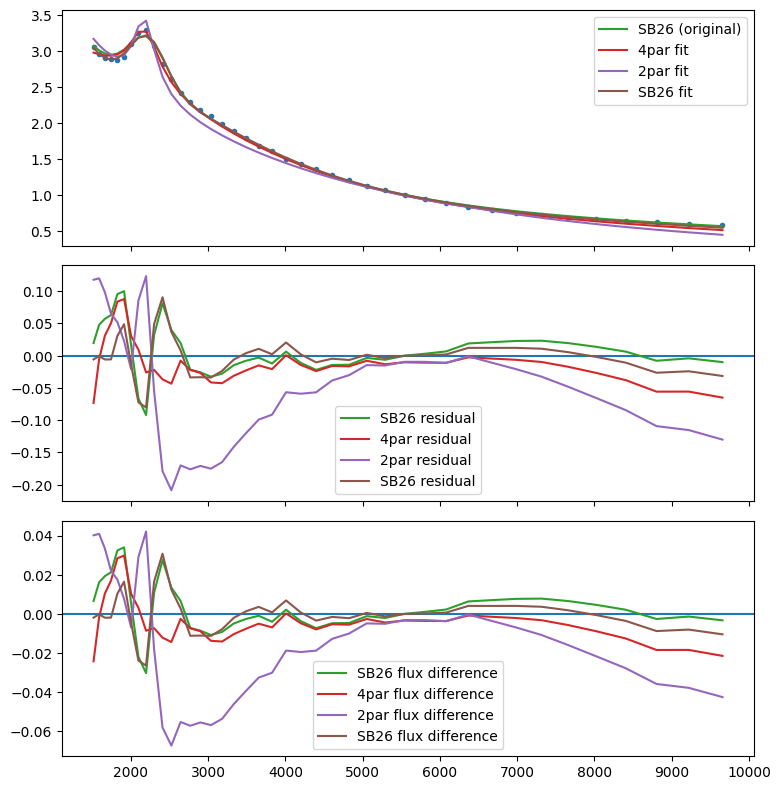

In [264]:
fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axs[0].plot(lam, A_over_Av[idx], '.', color='C0')
axs[1].axhline(0, color='C0')
axs[2].axhline(0, color='C0')

# Calzetti_pred = attenuation_curves.Li_08_fit_noratio(lam*1e-4, 44.9, 7.56, 61.2, 0.)
# axs[0].plot(lam, Calzetti_pred, label='Calzetti', color='C1')
# axs[1].plot(lam, Calzetti_pred - A_over_Av[idx], label='Calzetti residual', color='C1')

SB26_pred = func_SB26(lam, *SB26_pars[idx])
axs[0].plot(lam, SB26_pred, label='SB26 (original)', color='C2')
axs[1].plot(lam, SB26_pred - A_over_Av[idx], label='SB26 residual', color='C2')
df_F = 10. ** (0.4 * Av[idx] * (SB26_pred - A_over_Av[idx])) - 1.0
axs[2].plot(lam, df_F, label='SB26 flux difference', color='C2')

if success_4par:
    Li_pred = attenuation_curves.Li_08_fit_noratio(lam*1e-4, *popt_4par)
    axs[0].plot(lam, Li_pred, label='4par fit', color='C3')
    axs[1].plot(lam, Li_pred - A_over_Av[idx], label='4par residual', color='C3')
    df_F = 10. ** (0.4 * Av[idx] * (Li_pred - A_over_Av[idx])) - 1.0
    axs[2].plot(lam, df_F, label='4par flux difference', color='C3')

if success_2par:
    p2_pred = attenuation_curves.Att_Curve_2param(lam,B=popt_2par[0],delta=popt_2par[1])
    axs[0].plot(lam, p2_pred, label='2par fit', color='C4')
    axs[1].plot(lam, p2_pred - A_over_Av[idx], label='2par residual', color='C4')
    df_F = 10. ** (0.4 * Av[idx] * (p2_pred - A_over_Av[idx])) - 1.0
    axs[2].plot(lam, df_F, label='2par flux difference', color='C4')

if success_SB26:
    SB26_fit_pred = func_SB26(lam, *popt_SB26)
    axs[0].plot(lam, SB26_fit_pred, label='SB26 fit', color='C5')
    axs[1].plot(lam, SB26_fit_pred - A_over_Av[idx], label='SB26 residual', color='C5')
    df_F = 10. ** (0.4 * Av[idx] * (SB26_fit_pred - A_over_Av[idx])) - 1.0
    axs[2].plot(lam, df_F, label='SB26 flux difference', color='C5')

for ax in axs:
    ax.legend()
fig.tight_layout()

In [265]:
# Try to fit the SB26 function to the 4par fit results and see if we can get a good fit
A_4par = attenuation_curves.Li_08_fit_noratio(lam*1e-4, *popt_4par)
try:
    popt_SB26_from_4par, success_SB26_from_4par = fit_literature.run_fit(
                        func_SB26, 
                        lam, A_4par, 
                        bounds = bounds_SB26,
                        all_p0=all_p0_SB26)
    fit_nb = func_SB26(lam,B0=popt_SB26_from_4par[0],B1s=popt_SB26_from_4par[1],B2s=popt_SB26_from_4par[2],B3=popt_SB26_from_4par[3])
    rmse_SB26_from_4par = np.sqrt(np.mean((A_4par - fit_nb)**2))
except RuntimeError as e:
    print(f"Galaxy ID: {id_data['galaxy_id'].iloc[idx]}, LoS: {id_data['los'].iloc[idx]}, SB26 fit from 4par failed with error: {e}")
    popt_SB26_from_4par = [None, None, None, None]   
    success_SB26_from_4par = False 
    rmse_SB26_from_4par = None
res_SB26_from_4par = {'params': popt_SB26_from_4par, 'rmse': rmse_SB26_from_4par, 'success': success_SB26_from_4par}

# Try to fit the SB26 function to the 2par fit results and see if we can get a good fit
A_2par = attenuation_curves.Att_Curve_2param(lam,B=popt_2par[0],delta=popt_2par[1])
try:
    popt_SB26_from_2par, success_SB26_from_2par = fit_literature.run_fit(
                        func_SB26, 
                        lam, A_2par, 
                        bounds = bounds_SB26,
                        all_p0=all_p0_SB26)
    fit_nb = func_SB26(lam,B0=popt_SB26_from_2par[0],B1s=popt_SB26_from_2par[1],B2s=popt_SB26_from_2par[2],B3=popt_SB26_from_2par[3])
    rmse_SB26_from_2par = np.sqrt(np.mean((A_2par - fit_nb)**2))
except RuntimeError as e:
    print(f"Galaxy ID: {id_data['galaxy_id'].iloc[idx]}, LoS: {id_data['los'].iloc[idx]}, SB26 fit from 2par failed with error: {e}")
    popt_SB26_from_2par = [None, None, None, None]   
    success_SB26_from_2par = False 
    rmse_SB26_from_2par = None
res_SB26_from_2par = {'params': popt_SB26_from_2par, 'rmse': rmse_SB26_from_2par, 'success': success_SB26_from_2par}

print(res_SB26_from_4par)
print(res_SB26_from_2par)


{'params': array([ 0.64752079, -0.0746009 ,  0.4689168 ,  2.37518587]), 'rmse': np.float64(0.036907757142329974), 'success': True}
{'params': array([ 0.91934238, -0.19208016,  0.25707244,  2.86797997]), 'rmse': np.float64(0.07310112548200082), 'success': True}


Text(0.5, 1.0, 'SB26 fit from 2par')

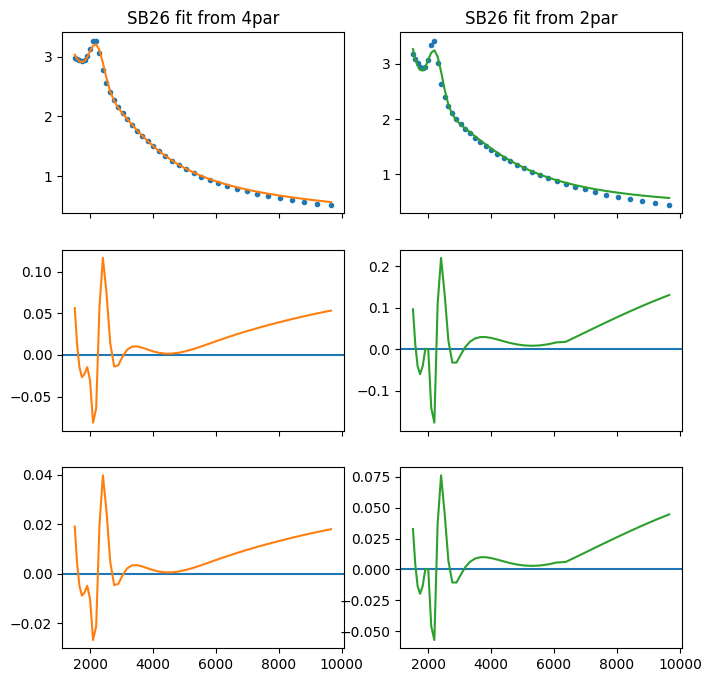

In [266]:
fig, axs = plt.subplots(3, 2, figsize=(8, 8), sharex=True)

axs[0, 0].plot(lam, A_4par, '.', color='C0')
axs[1, 0].axhline(0, color='C0')
axs[2, 0].axhline(0, color='C0')
axs[0, 1].plot(lam, A_2par, '.', color='C0')
axs[1, 1].axhline(0, color='C0')
axs[2, 1].axhline(0, color='C0')

if success_SB26_from_4par:
    SB26_from_4par_pred = func_SB26(lam, *popt_SB26_from_4par)
    axs[0, 0].plot(lam, SB26_from_4par_pred, label='SB26 from 4par fit', color='C1')
    axs[1, 0].plot(lam, SB26_from_4par_pred - A_4par, label='SB26 from 4par residual', color='C1')
    df_F = 10. ** (0.4 * Av[idx] * (SB26_from_4par_pred - A_4par)) - 1.0
    axs[2, 0].plot(lam, df_F, label='SB26 from 4par flux difference', color='C1')

if success_SB26_from_2par:
    SB26_from_2par_pred = func_SB26(lam, *popt_SB26_from_2par)
    axs[0, 1].plot(lam, SB26_from_2par_pred, label='SB26 from 2par fit', color='C2')
    axs[1, 1].plot(lam, SB26_from_2par_pred - A_2par, label='SB26 from 2par residual', color='C2')
    df_F = 10. ** (0.4 * Av[idx] * (SB26_from_2par_pred - A_2par)) - 1.0
    axs[2, 1].plot(lam, df_F, label='SB26 from 2par flux difference', color='C2')

axs[0,0].set_title('SB26 fit from 4par')
axs[0,1].set_title('SB26 fit from 2par')

# Analyse Results

In [4]:
df = pd.read_csv('fit_results_MW.txt', sep=' ', header=0)
df.head(5)

,galaxy_id,los,A_V,4par_c1,4par_c2,4par_c3,4par_c4,4par_rmse,4par_success,2par_B,...,SB26_from_4par_B2s,SB26_from_4par_B3,SB26_from_4par_rmse,SB26_from_4par_success,SB26_from_2par_B0,SB26_from_2par_B1s,SB26_from_2par_B2s,SB26_from_2par_B3,SB26_from_2par_rmse,SB26_from_2par_success
0,11,0,0.095220,144.243758,1.514388,2.086983,0.315737,0.389851,True,12.043883,...,-0.196457,5.044991,0.218958,True,6.867026,-0.795525,1.057618,6.035235,0.449315,True
1,11,1,0.090241,139.648934,1.530399,1.990253,0.326502,0.385568,True,12.384817,...,-0.080514,5.120438,0.224222,True,7.126425,-0.820074,1.095576,6.089197,0.466369,True
2,11,2,0.175579,122.512383,1.447699,2.405791,0.194876,0.318760,True,7.950764,...,-0.658828,4.289960,0.144094,True,3.945106,-0.518103,0.649082,5.271915,0.258216,True
3,11,3,0.075193,-1000.000000,1.752018,38.707618,0.373327,1.827338,True,14.062435,...,7.595271,5.574463,0.455595,True,8.468509,-0.952442,1.303158,6.359965,0.554606,True
4,11,4,0.170062,111.174719,1.441576,2.035011,0.205525,0.323374,True,8.252178,...,-0.597056,4.416519,0.147903,True,4.168040,-0.542490,0.682575,5.359739,0.272624,True


Number of successful 4par fits: 1198 (99.8%)
Number of successful 2par fits: 1200 (100.0%)


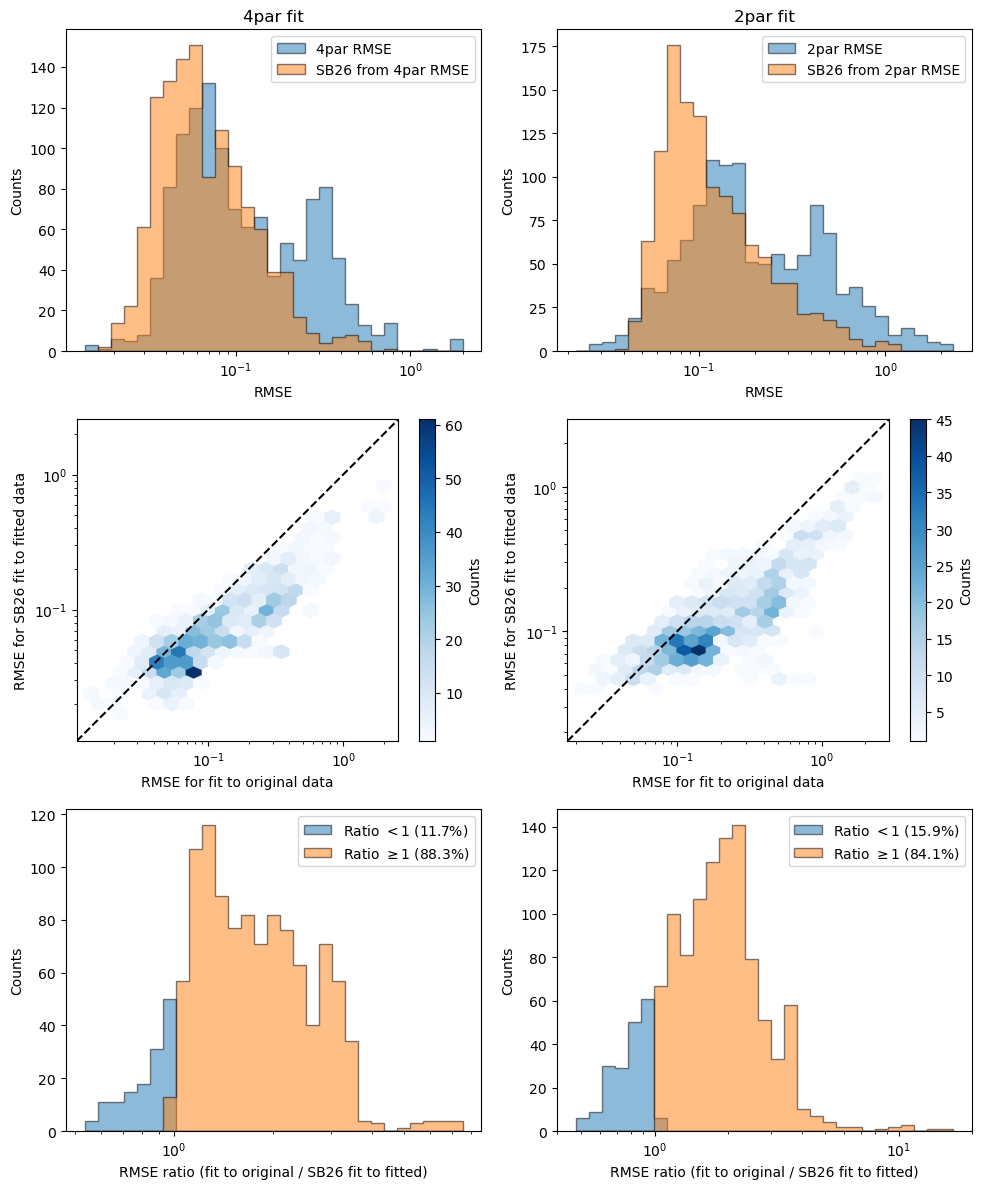

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(10, 12))

# bin_type = 'linear'
bin_type = 'log'
nbin_1d = 30
nbin_2d = 20

hist_kwargs = {"alpha": 0.5, "density": False, "histtype": 'stepfilled', "edgecolor": 'black'}
hexbin_kwargs = {"cmap": 'Blues', "gridsize": nbin_2d, "xscale": bin_type, "yscale": bin_type, "mincnt": 1}

mask_4par = df['4par_success'] & df['SB26_from_4par_success']
print(f"Number of successful 4par fits: {mask_4par.sum()} ({mask_4par.sum()/len(df)*100:.1f}%)")
bin_min = min(df['4par_rmse'][mask_4par].min(), df['SB26_from_4par_rmse'][mask_4par].min())
bin_max = max(df['4par_rmse'][mask_4par].max(), df['SB26_from_4par_rmse'][mask_4par].max())
if bin_type == 'linear':
    bins = np.linspace(bin_min, bin_max, nbin_1d)
elif bin_type == 'log':
    bins = np.logspace(np.log10(bin_min), np.log10(bin_max), nbin_1d)
else:
    raise ValueError(f"Unknown bin_type: {bin_type}")
axs[0,0].hist(df['4par_rmse'][mask_4par], label='4par RMSE', bins=bins, **hist_kwargs)
axs[0,0].hist(df['SB26_from_4par_rmse'][mask_4par], label='SB26 from 4par RMSE', bins=bins, **hist_kwargs)
hb = axs[1,0].hexbin(df['4par_rmse'][mask_4par], df['SB26_from_4par_rmse'][mask_4par], **hexbin_kwargs)
cb = fig.colorbar(hb, ax=axs[1,0])
cb.set_label('Counts')
ratio = df['4par_rmse'][mask_4par] / df['SB26_from_4par_rmse'][mask_4par]
bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), nbin_1d)
m = ratio < 1
label = f'Ratio $< 1$ ({m.sum()/len(ratio)*100:.1f}%)'
axs[2,0].hist(ratio[m], bins=bins, **hist_kwargs, label=label)
label = f'Ratio $\\geq 1$ ({(~m).sum()/len(ratio)*100:.1f}%)'
axs[2,0].hist(ratio[~m], bins=bins, **hist_kwargs, label=label)

mask_2par = df['2par_success'] & df['SB26_from_2par_success']
print(f"Number of successful 2par fits: {mask_2par.sum()} ({mask_2par.sum()/len(df)*100:.1f}%)")
bin_min = min(df['2par_rmse'][mask_2par].min(), df['SB26_from_2par_rmse'][mask_2par].min())
bin_max = max(df['2par_rmse'][mask_2par].max(), df['SB26_from_2par_rmse'][mask_2par].max())
if bin_type == 'linear':
    bins = np.linspace(bin_min, bin_max, nbin_1d)
elif bin_type == 'log':
    bins = np.logspace(np.log10(bin_min), np.log10(bin_max), nbin_1d)
else:
    raise ValueError(f"Unknown bin_type: {bin_type}")
axs[0,1].hist(df['2par_rmse'][mask_2par], label='2par RMSE', bins=bins, **hist_kwargs)
axs[0,1].hist(df['SB26_from_2par_rmse'][mask_2par], label='SB26 from 2par RMSE', bins=bins, **hist_kwargs)
hb = axs[1,1].hexbin(df['2par_rmse'][mask_2par], df['SB26_from_2par_rmse'][mask_2par], **hexbin_kwargs)
cb = fig.colorbar(hb, ax=axs[1,1])
cb.set_label('Counts')
ratio = df['2par_rmse'][mask_2par] / df['SB26_from_2par_rmse'][mask_2par]
bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), nbin_1d)
m = ratio < 1
label = f'Ratio $< 1$ ({m.sum()/len(ratio)*100:.1f}%)'
axs[2,1].hist(ratio[m], bins=bins, **hist_kwargs, label=label)
label = f'Ratio $\\geq 1$ ({(~m).sum()/len(ratio)*100:.1f}%)'
axs[2,1].hist(ratio[~m], bins=bins, **hist_kwargs, label=label)

for ax in axs[0,:]:
    ax.set_xlabel('RMSE')
    ax.set_ylabel('Counts')
    ax.legend()
    ax.set_xscale(bin_type)

for ax in axs[1,:]:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
    ax.plot(x, x, color='black', linestyle='--')
    ax.set_xlim(x)
    ax.set_ylim(x)
    ax.set_aspect('equal')
    ax.set_xlabel('RMSE for fit to original data')
    ax.set_ylabel('RMSE for SB26 fit to fitted data')

for ax in axs[2,:]:
    ax.legend()
    ax.set_xscale('log')
    ax.set_xlabel('RMSE ratio (fit to original / SB26 fit to fitted)')
    ax.set_ylabel('Counts')

axs[0,0].set_title('4par fit')
axs[0,1].set_title('2par fit')

fig.tight_layout()